## Install dependencies and Imports


In [ ]:
!pip -q install praw nltk networkx python-louvain tqdm
!pip -q install spacy wordcloud
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Core data handling
import pandas as pd
import numpy as np
import time
from collections import defaultdict, Counter
from tqdm import tqdm

# Reddit data collection
import praw

# Network analysis
import networkx as nx
import community.community_louvain as community_louvain

# NLP and sentiment analysis
import nltk
nltk.download("punkt")
# We use the VADER sentiment analyzer, which is well suited for short, informal social media texts.
nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer
import spacy
import re

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Logging / utilities
import logging

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
import os, pandas as pd

DATA_PATH = "data/raw_reddit_comments.csv"
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)

REBUILD_DATA = False


Mounted at /content/drive


### Reddit API Configuration

In order to collect data from Reddit, we use the PRAW (Python Reddit API Wrapper) library.  
This block initializes a read-only connection to the Reddit API using a dedicated client configuration.


In [ ]:
try:
    from dotenv import load_dotenv
    load_dotenv()  # load .env file into os.environ if present
except ImportError:
    pass  # python-dotenv not installed; rely on env vars being set externally

import os

# Load credentials from environment variables (primary) or Google Colab Secrets (fallback).
try:
    from google.colab import userdata as _colab_userdata
    _colab_available = True
except ImportError:
    _colab_available = False

def _get_secret(name, default=None):
    val = os.environ.get(name)
    if val:
        return val
    if _colab_available:
        try:
            return _colab_userdata.get(name)
        except Exception:
            pass
    return default

REDDIT_CLIENT_ID     = _get_secret("REDDIT_CLIENT_ID")
REDDIT_CLIENT_SECRET = _get_secret("REDDIT_CLIENT_SECRET")
REDDIT_USER_AGENT    = _get_secret("REDDIT_USER_AGENT", "SMA_project (by your_username)")

if not REDDIT_CLIENT_ID or not REDDIT_CLIENT_SECRET:
    raise RuntimeError(
        "Set REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET as environment variables before running."
    )

# Initialize Reddit API connection
reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT
)
# Ensure read-only access
print("read_only:", reddit.read_only)


read_only: True


## Configuration

We limit data collection to control runtime and network size.


In [ ]:
SUBREDDIT_NAME = "alcohol"

MAX_POSTS = 400
MAX_COMMENTS = 10000
MAX_NODES = 5000

##Data containers + subreddit object:

In [ ]:
rows = []
users_set = set()

subreddit = reddit.subreddit(SUBREDDIT_NAME)

##Data collection (interactions):

In [ ]:
# Cleaning the output
logging.getLogger("praw").setLevel(logging.ERROR)

In [ ]:
# Iterate over submissions in the selected subreddit
for submission in tqdm(subreddit.hot(limit=MAX_POSTS)):

    # Expand all comment threads (remove "load more comments")
    submission.comments.replace_more(limit=0)

    # Extract post-level metadata
    post_author = submission.author.name if submission.author else None
    post_id = submission.id
    post_title = submission.title

    # Iterate over comments in the submission (limited for runtime control)
    for comment in submission.comments.list()[:MAX_COMMENTS]:

        # Skip deleted users or posts with missing authors
        if not comment.author or not post_author:
            continue

        # Author of the current comment
        commenter = comment.author.name
        parent_author = None

        # Identify reply-to-reply interactions (comment replying to another comment)
        try:
            parent = comment.parent()
            if hasattr(parent, "author") and parent.author:
                parent_author = parent.author.name
        except Exception:
            # In rare cases, parent retrieval may fail
            pass

        # Record the interaction
        rows.append({
            "commenter": commenter,
            # If replying to another comment, link to that user; otherwise link to post author
            "replied_to": parent_author if parent_author else post_author,
            "comment_text": comment.body,
            "post_id": post_id,
            "post_title": post_title,
            # Distinguish between reply-to-user and reply-to-post interactions
            "type": "reply_to_user" if parent_author else "reply_to_post"
        })

        # Update the set of observed users
        users_set.update([commenter, post_author])
        if parent_author:
            users_set.add(parent_author)

        # Stop collecting comments if the maximum number of users is reached
        if len(users_set) >= MAX_NODES:
            break

    # Stop iterating over submissions once the user limit is reached
    if len(users_set) >= MAX_NODES:
        break


400it [02:36,  2.56it/s]


##Build DataFrame + basic checks + export:
After collecting all user interactions, we convert the data into a structured DataFrame.
To ensure reproducibility, data were collected once from Reddit and saved locally. All analyses and visualizations are based on this fixed dataset unless explicitly regenerated.

In [ ]:
if (not os.path.exists(DATA_PATH)) or REBUILD_DATA:
    # Build DataFrame from collected rows
    df = pd.DataFrame(rows)

    print("Rows:", df.shape[0])
    print("Unique users:", len(set(df["commenter"]).union(set(df["replied_to"]))))

    df.to_csv(DATA_PATH, index=False)
    print("Saved dataset to:", DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)
    print("Loaded existing dataset from:", DATA_PATH)

df.head()

Rows: 2932
Unique users: 1316
Saved dataset to: /content/drive/MyDrive/SMA_Project/data/raw_reddit_comments.csv


,commenter,replied_to,comment_text,post_id,post_title,type
0,Fit-Elephant8778,KingOfTheStuffed,These look like they’d be bomb and get you fuc...,1qbagr8,Pretty colors!,reply_to_user
1,TheLoneWander101,KingOfTheStuffed,I feel hunger over just looking at these,1qbagr8,Pretty colors!,reply_to_user
2,KingOfTheStuffed,Fit-Elephant8778,They are great! I've been getting them off and...,1qbagr8,Pretty colors!,reply_to_user
3,Soggy_Ground_9323,rcborg,for a typical alkieeeee.....this would be done...,1qafb44,True alcoholic life hack.,reply_to_user
4,zambulu,rcborg,"It's still expensive, if those are US dollars....",1qafb44,True alcoholic life hack.,reply_to_user


##Clean data (remove self-loops) + build Directed graph:

In [ ]:
# Remove self-loops (users replying to themselves)
df_clean = df[df["commenter"] != df["replied_to"]].copy()

# Build a directed interaction graph: commenter -> replied_to
G_dir = nx.DiGraph()
G_dir.add_edges_from(zip(df_clean["commenter"], df_clean["replied_to"]))

print("Directed graph")
print("Nodes:", G_dir.number_of_nodes())
print("Edges:", G_dir.number_of_edges())


Directed graph
Nodes: 1315
Edges: 2584


##Giant Component (Weakly) + undirected version for Louvain:

In [ ]:
# Extract the giant weakly connected component (GWCC)
wcc = sorted(nx.weakly_connected_components(G_dir), key=len, reverse=True)
GWCC = wcc[0]

G_dir_gc = G_dir.subgraph(GWCC).copy()

print("Giant weakly connected component (GWCC) nodes:", G_dir_gc.number_of_nodes())
print("GWCC edges:", G_dir_gc.number_of_edges())

# Convert to undirected graph for community detection and structural metrics
G_und_gc = G_dir_gc.to_undirected()


Giant weakly connected component (GWCC) nodes: 1291
GWCC edges: 2564


##Network Structure Metrics:

In [ ]:
# Compute global network metrics on the undirected giant component
density = nx.density(G_und_gc)
clustering = nx.average_clustering(G_und_gc)
assortativity = nx.degree_assortativity_coefficient(G_und_gc)

print("Density:", round(density, 5))
print("Average clustering coefficient:", round(clustering, 5))
print("Degree assortativity:", round(assortativity, 5))

Density: 0.00258
Average clustering coefficient: 0.03424
Degree assortativity: -0.16462


##Centrality (on Giant Component):

In [ ]:
SEED = 42  # fixed seed for reproducibility

# Degree centrality: local connectivity/activity
deg_cent = nx.degree_centrality(G_und_gc)

# Approximate betweenness centrality
bet_cent = nx.betweenness_centrality(G_und_gc, k=200, seed=SEED)

# Closeness centrality
close_cent = nx.closeness_centrality(G_und_gc)

print("Centralities computed ✓")

Centralities computed ✓


### Hubs and Bridges Identification (Quick Inspection)

We perform a preliminary inspection of structurally important users.
High degree centrality nodes are interpreted as hubs, while nodes in the top 5% of betweenness centrality are considered bridges connecting different parts of the network.

In [ ]:
# Top hubs by degree centrality (highly connected users)
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

# Top bridge nodes by betweenness centrality
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 by degree centrality:")
top_deg
print("Top 10 by betweenness centrality:")
top_bet

Top 10 by degree centrality:
Top 10 by betweenness centrality:


[('SammaJones', 0.26328835041891846),
 ('No_Consideration7925', 0.25006684486170005),
 ('Pizzafriedchickenn', 0.15355315129988026),
 ('Johnporkh', 0.1510222574627762),
 ('Queasy_Knowledge_853', 0.06376994721613663),
 ('Valuable-Location-89', 0.06303728989393319),
 ('PinkysAvenger', 0.05645471602391886),
 ('ezpricey', 0.050530101057496786),
 ('ChronicKush69', 0.046433054677760766),
 ('Electrical-Gear4483', 0.03973538336340612)]

##Bridge Nodes (95th percentile):

In [ ]:
threshold = np.percentile(list(bet_cent.values()), 95)

bridge_nodes = {n: bet_cent[n] for n in G_und_gc.nodes() if bet_cent[n] > threshold}
top_bridges = sorted(bridge_nodes.items(), key=lambda x: x[1], reverse=True)[:10]

print("Betweenness 95th percentile threshold:", threshold)
print("Top bridge nodes:")
top_bridges

Betweenness 95th percentile threshold: 0.010569275613077724
Top bridge nodes:


[('SammaJones', 0.26328835041891846),
 ('No_Consideration7925', 0.25006684486170005),
 ('Pizzafriedchickenn', 0.15355315129988026),
 ('Johnporkh', 0.1510222574627762),
 ('Queasy_Knowledge_853', 0.06376994721613663),
 ('Valuable-Location-89', 0.06303728989393319),
 ('PinkysAvenger', 0.05645471602391886),
 ('ezpricey', 0.050530101057496786),
 ('ChronicKush69', 0.046433054677760766),
 ('Electrical-Gear4483', 0.03973538336340612)]

##Build Node Metrics DataFrame + Export CSV
We aggregate the computed centrality measures into a node-level table.

In [ ]:
# Build a node-level DataFrame with centrality metrics
df_nodes = pd.DataFrame({
    "user": list(G_und_gc.nodes()),
    "degree_centrality": [deg_cent[u] for u in G_und_gc.nodes()],
    "betweenness_centrality": [bet_cent[u] for u in G_und_gc.nodes()],
    "closeness_centrality": [close_cent[u] for u in G_und_gc.nodes()],
})

# Export node-level metrics for further analysis and reproducibility
df_nodes.to_csv("node_centrality_metrics.csv", index=False)

print("Saved:", "node_centrality_metrics.csv")
df_nodes.head()


Saved: node_centrality_metrics.csv


,user,degree_centrality,betweenness_centrality,closeness_centrality
0,Fit-Elephant8778,0.001550,0.002493,0.226554
1,KingOfTheStuffed,0.001550,0.000031,0.197368
2,TheLoneWander101,0.003876,0.004207,0.231390
3,Soggy_Ground_9323,0.007752,0.009410,0.286858
4,rcborg,0.012403,0.015518,0.269367


##Community Detection (Louvain) + Resolution Sensitivity
We apply the Louvain method to detect communities in the undirected giant component.

In [ ]:
# Run Louvain community detection with configurable resolution
def run_louvain(G_und, res=1.0, seed=SEED):
    part = community_louvain.best_partition(
        G_und,
        resolution=res,
        random_state=seed
    )
    # Modularity score of the partition
    Q = community_louvain.modularity(part, G_und)
    # Number of detected communities
    k = len(set(part.values()))
    return part, Q, k

# Inspect the effect of resolution on number of communities and modularity
for res in [0.5, 1.0, 1.5]:
    part_tmp, Q_tmp, k_tmp = run_louvain(G_und_gc, res=res, seed=SEED)
    print(f"resolution={res} | communities={k_tmp} | modularity={Q_tmp:.4f}")

resolution=0.5 | communities=84 | modularity=0.5863
resolution=1.0 | communities=21 | modularity=0.6162
resolution=1.5 | communities=37 | modularity=0.6088


##Choose partition + Export user_communities.csv
Based on the resolution analysis, we select a single resolution value and compute the final Louvain partition.

In [ ]:
# Select the main resolution value for community detection
RESOLUTION_MAIN = 1.0

# Run Louvain with the chosen resolution
partition, modularity, n_comms = run_louvain(
    G_und_gc,
    res=RESOLUTION_MAIN,
    seed=SEED
)

print("Chosen Louvain partition")
print("resolution:", RESOLUTION_MAIN)
print("communities:", n_comms)
print("modularity:", round(modularity, 4))

# Build a user-to-community mapping DataFrame
df_communities = pd.DataFrame({
    "user": list(partition.keys()),
    "community": list(partition.values())
})

# Export community assignments for reproducibility and downstream analysis
df_communities.to_csv("user_communities.csv", index=False)
print("Saved:", "user_communities.csv")

df_communities.head()


Chosen Louvain partition
resolution: 1.0
communities: 21
modularity: 0.6162
Saved: user_communities.csv


,user,community
0,Fit-Elephant8778,0
1,KingOfTheStuffed,0
2,TheLoneWander101,0
3,Soggy_Ground_9323,1
4,rcborg,1


### Community Structural Summary

For each detected community, we compute basic structural properties:
community size, internal connectivity, external boundary edges, and the most central users (hubs).

In [ ]:
# Build mapping: community_id -> list of nodes
comm_nodes = defaultdict(list)
for node, cid in partition.items():
    comm_nodes[cid].append(node)

summary_rows = []
for cid, nodes in comm_nodes.items():
    # Subgraph induced by the community nodes
    sub = G_und_gc.subgraph(nodes)

    # Count internal edges within the community
    internal = sub.number_of_edges()

    # Count edges that connect this community to the rest of the graph
    node_set = set(nodes)
    boundary = 0
    for u in nodes:
        for v in G_und_gc.neighbors(u):
            if v not in node_set:
                boundary += 1

    # Undirected boundary edges are counted twice, so divide by 2
    external = int(boundary / 2)

    # Identify top-5 hubs inside the community by degree centrality
    hubs = sorted(
        [(n, deg_cent.get(n, 0)) for n in nodes],
        key=lambda x: x[1],
        reverse=True
    )[:5]

    # Store community-level structural summary
    summary_rows.append({
        "community": cid,
        "size": len(nodes),
        "internal_edges": internal,
        "external_edges": external,
        "top_hubs": hubs
    })

# Build summary table and sort communities by size
df_comm_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("size", ascending=False)
)

df_comm_summary.head(10)


,community,size,internal_edges,external_edges,top_hubs
3,3,108,139,80,"[(SammaJones, 0.07984496124031007), (petryan55..."
17,17,102,115,54,"[(Pizzafriedchickenn, 0.06899224806201551), (L..."
6,6,95,115,61,"[(No_Consideration7925, 0.08139534883720931), ..."
4,4,92,100,39,"[(Johnporkh, 0.07984496124031007), (TheBoneIdl..."
9,16,82,91,41,"[(Puzzleheaded-Gur-713, 0.017054263565891473),..."
0,0,81,96,48,"[(Valuable-Location-89, 0.04573643410852713), ..."
15,9,81,93,49,"[(Queasy_Knowledge_853, 0.020155038759689922),..."
12,19,75,83,46,"[(PinkysAvenger, 0.027906976744186046), (mndsm..."
8,8,63,68,27,"[(big40748, 0.011627906976744186), (defnot_ll,..."
10,12,57,61,25,"[(Wonderful_Host798, 0.02558139534883721), (Dr..."


##Community Size Distribution (clean table)

In [ ]:
# Select key structural metrics per community
df_comm_sizes = df_comm_summary[["community", "size", "internal_edges", "external_edges"]].copy()
df_comm_sizes.to_csv("community_summary.csv", index=False)

print("Saved:", "community_summary.csv")
df_comm_sizes.head(15)

Saved: community_summary.csv


,community,size,internal_edges,external_edges
3,3,108,139,80
17,17,102,115,54
6,6,95,115,61
4,4,92,100,39
9,16,82,91,41
0,0,81,96,48
15,9,81,93,49
12,19,75,83,46
8,8,63,68,27
10,12,57,61,25


##Select Top Communities:
Select the largest communities to improve visualization clarity and focus on the dominant structural groups in the network.

In [ ]:
# Count community sizes
community_sizes = Counter(partition.values())

# Top 10 communities by node count - used to filter the graph for visualization.
TOP_K = 10
top_comms_for_viz = {
    c for c, _ in community_sizes.most_common(TOP_K)
}

print("Top communities (for viz):", top_comms_for_viz)

Top communities: {0, 3, 4, 6, 8, 9, 12, 16, 17, 19}


##Filter Graph by Largest Communities:
Filter the graph to include only nodes belonging to the largest communities, reducing visual noise.

In [ ]:
nodes_to_draw = [
    n for n in G_und_gc.nodes()
    if partition[n] in top_comms_for_viz
]

H = G_und_gc.subgraph(nodes_to_draw).copy()

print("Nodes drawn:", H.number_of_nodes())
print("Edges drawn:", H.number_of_edges())

Nodes drawn: 836
Edges drawn: 1273


##Visualization Node Sizes:
 (computed in the Centrality cell) is reused here to scale node sizes. No recomputation needed.

In [ ]:
# deg_cent was computed in the Centrality cell above and is reused directly.
# node_sizes is computed in the visualization cell below for all G_und_gc nodes.


##Community-Based Network Visualization:
Visualizes the interaction network using a spring layout. Nodes are colored by community membership and sized by degree centrality. Only the largest communities are shown to improve interpretability.

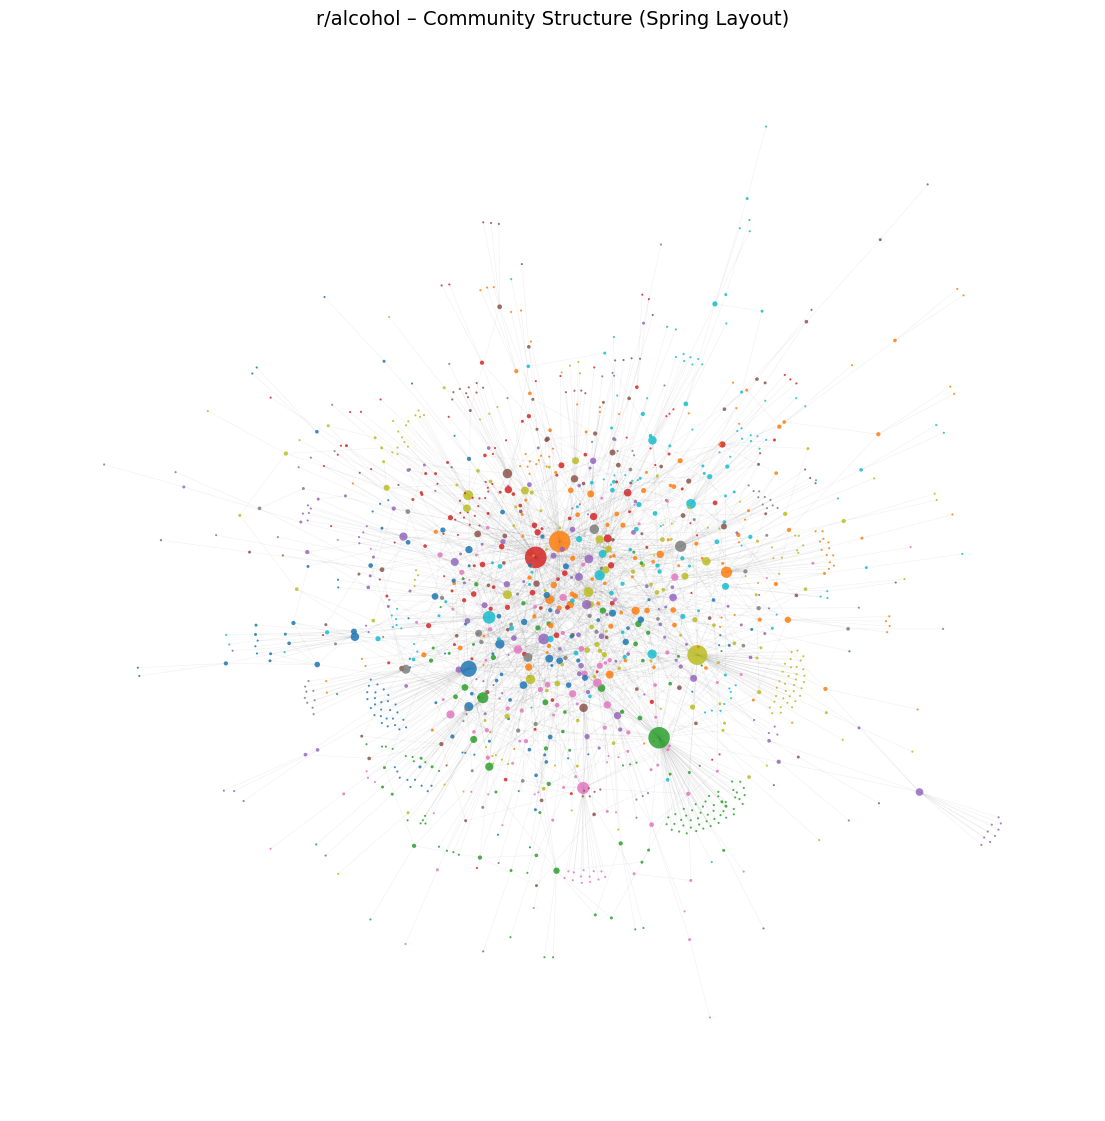

In [ ]:

G = G_und_gc  # Use the undirected giant component for visualization
part = partition  # Community assignment: node -> community id

plt.figure(figsize=(14, 14))

pos = nx.spring_layout(
    G,
    seed=SEED,
    k=0.15,
    iterations=200
)

nodelist = list(G.nodes())

node_colors = [part[n] for n in nodelist]

node_sizes = [3000 * deg_cent[n] for n in nodelist]

# Draw edges with low opacity to reduce clutter
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.05,
    width=0.5
)

# Draw nodes colored by community and sized by centrality
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodelist,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    alpha=0.85,
    linewidths=0.0
)

plt.title("r/alcohol – Community Structure (Spring Layout)", fontsize=14)
plt.axis("off")
plt.savefig("images/community-detection-louvain.png", dpi=150, bbox_inches="tight")
plt.show()


##spaCy pipeline (single consolidated load):

In [ ]:
# Load spaCy once with the dependency parser enabled.
# Noun chunks (used in build_freqs_for_community) require the parser;
# NER works fine with the parser active, so one pipeline config satisfies both steps.
nlp = spacy.load("en_core_web_sm")


##Choose top 5 largest communities
Attach community labels to each comment in order to analyze textual content at the community level.
We focus on the largest communities to ensure sufficient textual data per group.

In [ ]:
# Sanity checks to ensure required columns exist
assert {"commenter", "comment_text"}.issubset(df_clean.columns), "df_clean must include commenter, comment_text"
assert {"user", "community"}.issubset(df_communities.columns), "df_communities must include user, community"

# Attach community label to each comment based on the author
df_comm_text = df_clean.merge(
    df_communities[["user", "community"]],
    left_on="commenter",
    right_on="user",
    how="inner"
)

# Top 5 communities by unique-user count - used to select communities for word-cloud analysis.
top_comms_by_users = (
    df_communities["community"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

top_comms_by_users


[3, 17, 6, 4, 16]

##Text cleaning helpers and feature extraction:

In [ ]:
# spaCy pipeline is already loaded above with the parser enabled.


##Text cleaning helpers:

In [ ]:
# Regular expressions for URL removal and whitespace normalization
URL_RE = re.compile(r"https?://\S+|www\.\S+")
WS_RE = re.compile(r"\s+")

def clean_text(t: str) -> str:
    # Handle missing or non-string inputs safely
    if not isinstance(t, str):
        return ""

    t = t.lower()  # Lowercase text for normalization

    t = URL_RE.sub(" ", t)  # Remove URLs

    t = re.sub(r"[\r\n\t]", " ", t) # Remove line breaks and tabs

    t = WS_RE.sub(" ", t).strip()  # Collapse multiple spaces into a single space

    return t


# Extract lexical and semantic features from community texts using spaCy.
For each community, we collect frequent tokens, named entities, and noun chunks to characterize dominant topics and themes.

In [ ]:
def build_freqs_for_community(texts, batch_size=64, max_docs=None):
    # Counters for different linguistic features
    token_counter = Counter()
    ent_counter = Counter()
    chunk_counter = Counter()

    # Optional limit to keep runtime reasonable
    if max_docs is not None:
        texts = texts[:max_docs]

    # Clean and filter raw texts
    cleaned = [clean_text(t) for t in texts if isinstance(t, str) and t.strip()]

    # Process texts in batches using spaCy pipeline
    for doc in nlp.pipe(cleaned, batch_size=batch_size):

        for tok in doc:  #Tokens
            # Skip stopwords, punctuation, numbers, and spaces
            if tok.is_stop or tok.is_punct or tok.like_num or tok.is_space:
                continue
            if len(tok.text) < 3:
                continue

            # Focus on content-bearing parts of speech
            if tok.pos_ not in {"NOUN", "PROPN", "ADJ", "VERB"}:
                continue

            # Use lemma for normalization
            lemma = tok.lemma_.strip()
            if lemma and len(lemma) >= 3:
                token_counter[lemma] += 1

        # Named Entity
        for ent in doc.ents:
            # Keep only informative entity types
            if ent.label_ in {
                "PERSON", "ORG", "GPE", "NORP",
                "PRODUCT", "EVENT", "LAW", "WORK_OF_ART"
            }:
                val = ent.text.strip().lower()
                val = re.sub(r"\s+", " ", val)
                if len(val) >= 3:
                    ent_counter[val] += 1

        # Noun chunk
        for ch in doc.noun_chunks:
            val = ch.text.strip().lower()
            val = re.sub(r"\s+", " ", val)
            val = re.sub(r"[^a-z\s\-]", "", val).strip()

            # Filter very short or overly long phrases
            if len(val) >= 4 and len(val.split()) <= 4:
                # Skip chunks composed entirely of stopwords
                if all(w in nlp.Defaults.stop_words for w in val.split()):
                    continue
                chunk_counter[val] += 1

    # Return frequency dictionaries for downstream analysis
    return token_counter, ent_counter, chunk_counter


##Build “sun” wordcloud mask + plotting function:
Define utilities for visualizing community topics using word clouds.

In [ ]:
def circle_mask(size=900):
    # Create a circular mask for word cloud visualization
    y, x = np.ogrid[:size, :size]
    center = size / 2
    r = size / 2 - 5

    # Mask pixels outside the circle
    mask = (x - center) ** 2 + (y - center) ** 2 > r ** 2

    m = np.zeros((size, size), dtype=np.uint8)
    m[mask] = 255  # White pixels are masked out
    return m

# Precompute circular mask
MASK = circle_mask(900)

def plot_wordcloud(freqs, title, max_words=120, save_path=None):
    # Generate word cloud from frequency dictionary
    wc = WordCloud(
        width=900,
        height=900,
        background_color="white",
        mask=MASK,
        max_words=max_words,
        collocations=False
    ).generate_from_frequencies(freqs)

    # Plot the word cloud
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


##Generate 5 community wordclouds (tokens + entities + chunks combined):

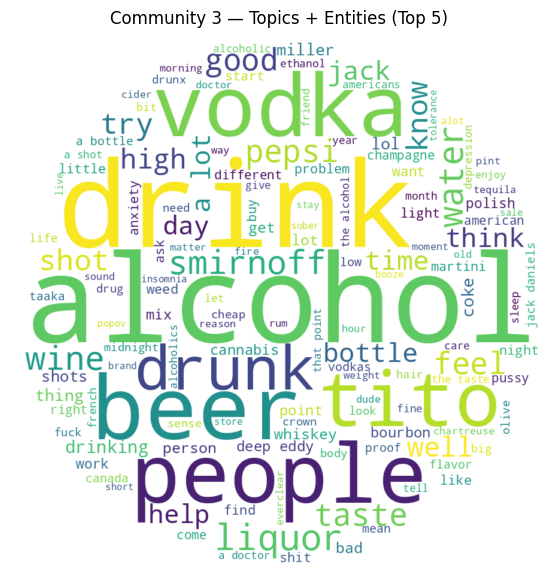


Community 3 | comments: 345 | unique users: 90
Top entities: [('tito', 8), ('pepsi', 6), ('miller', 5), ('polish', 4), ('american', 3), ('french', 3), ('jack daniels', 3), ('smirnoff', 3), ('n’t', 2), ('jack', 2)]
Top noun chunks: [('alcohol', 35), ('beer', 16), ('people', 15), ('water', 10), ('a lot', 10), ('tito', 10), ('vodka', 9), ('shots', 8), ('liquor', 8), ('smirnoff', 8)]
------------------------------------------------------------


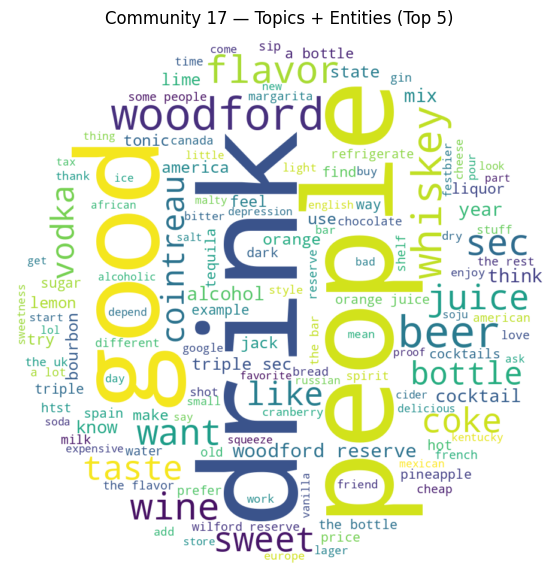


Community 17 | comments: 211 | unique users: 98
Top entities: [('sec', 9), ('woodford reserve', 5), ('america', 3), ('woodford', 3), ('african', 2), ('american', 2), ('american honey', 2), ('russian', 2), ('canada', 2), ('mexican', 2)]
Top noun chunks: [('people', 13), ('whiskey', 9), ('woodford', 9), ('triple sec', 8), ('beer', 7), ('wine', 7), ('a bottle', 6), ('coke', 6), ('cointreau', 6), ('woodford reserve', 5)]
------------------------------------------------------------


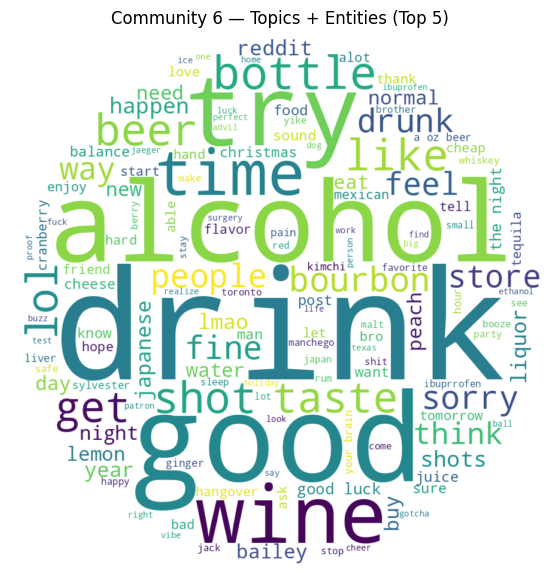


Community 6 | comments: 295 | unique users: 70
Top entities: [('japanese', 3), ('evan williams', 2), ('mexican', 2), ('wha wha', 1), ('abc', 1), ('😔 watery', 1), ('kentucky', 1), ('jack', 1), ('jim beam', 1), ('american', 1)]
Top noun chunks: [('shots', 5), ('alcohol', 5), ('good luck', 4), ('wine', 4), ('the night', 4), ('bourbon', 3), ('people', 3), ('your brain', 3), ('lmao', 3), ('a oz beer', 3)]
------------------------------------------------------------


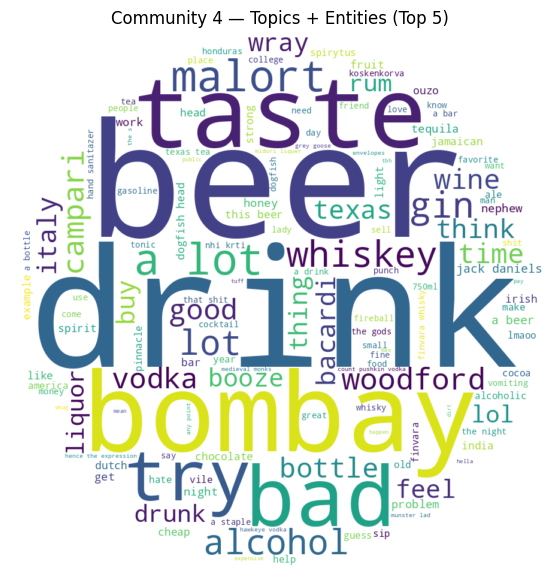


Community 4 | comments: 160 | unique users: 90
Top entities: [('bombay', 5), ('texas', 3), ('malort', 3), ('italy', 2), ('woodford', 2), ('irish', 2), ('jamaican', 2), ('jack daniels', 2), ('bacardi', 2), ('campari', 2)]
Top noun chunks: [('a lot', 9), ('beer', 7), ('bombay', 6), ('malort', 4), ('a beer', 4), ('alcohol', 3), ('this beer', 3), ('wine', 3), ('woodford', 3), ('taste', 3)]
------------------------------------------------------------


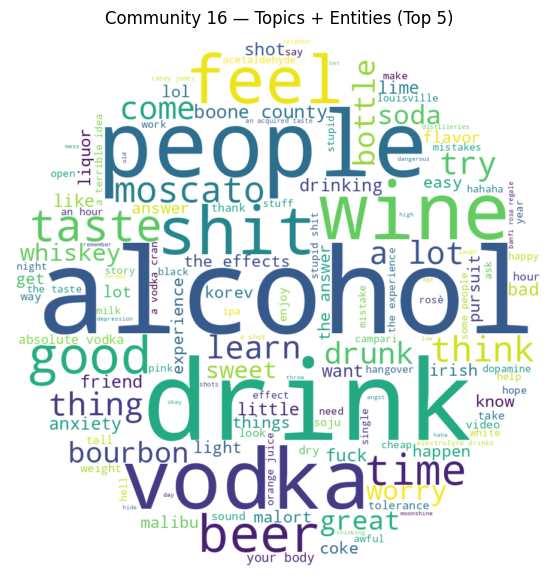


Community 16 | comments: 155 | unique users: 75
Top entities: [('irish', 2), ('boone county', 2), ('moscato', 2), ('korev', 2), ('orange juice', 1), ('malibu', 1), ('bitters soda campari soda', 1), ('german', 1), ('ricky henderson', 1), ('malort', 1)]
Top noun chunks: [('alcohol', 14), ('people', 8), ('a lot', 5), ('the effects', 3), ('things', 3), ('beer', 3), ('the answer', 3), ('your body', 3), ('shit', 3), ('wine', 3)]
------------------------------------------------------------


In [ ]:
# Limit the number of texts processed per community to control runtime
COMMUNITY_TEXT_LIMIT = 6000  # adjust if needed

for cid in top_comms_by_users:
    # Extract comments belonging to the current community
    sub = df_comm_text[df_comm_text["community"] == cid]
    texts = sub["comment_text"].dropna().tolist()

    # Extract token, entity, and noun-chunk frequencies
    tok_c, ent_c, chunk_c = build_freqs_for_community(
        texts,
        batch_size=64,
        max_docs=COMMUNITY_TEXT_LIMIT
    )

    # Combine different linguistic features with simple weighting
    combined = Counter()

    # Tokens dominate the representation
    combined.update(tok_c)

    # Boost noun chunks to emphasize multi-word topics
    for k, v in chunk_c.items():
        combined[k] += int(v * 2)

    # Boost named entities slightly
    for k, v in ent_c.items():
        combined[k] += int(v * 2)

    # Plot word cloud for the community
    plot_wordcloud(
        combined,
        title=f"Community {cid} — Topics + Entities (Top 5)",
        max_words=140,
        save_path=f"images/community-{cid}-wordcloud.png"
    )

    # Sanity check: print basic stats and top extracted features
    print(f"\nCommunity {cid} | comments: {len(texts)} | unique users: {sub['commenter'].nunique()}")
    print("Top entities:", ent_c.most_common(10))
    print("Top noun chunks:", chunk_c.most_common(10))
    print("-" * 60)


##Build Sentiment Dataset (merge comments + communities):

In [ ]:
# Ensure required columns exist before merging
required_cols = {"comment_text", "commenter"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"df is missing columns: {missing}. Expected at least: {required_cols}"
    )

# Merge comments with community labels based on the author
df_sent = df.merge(
    df_communities[["user", "community"]],
    left_on="commenter",
    right_on="user",
    how="inner"
).copy()

# Keep only columns relevant for sentiment analysis
df_sent = (
    df_sent[["commenter", "comment_text", "community"]]
    .rename(columns={"commenter": "user"})
)

print("Merged rows:", len(df_sent))
df_sent.head()


Merged rows: 2907


,user,comment_text,community
0,Fit-Elephant8778,These look like they’d be bomb and get you fuc...,0
1,TheLoneWander101,I feel hunger over just looking at these,0
2,KingOfTheStuffed,They are great! I've been getting them off and...,0
3,Soggy_Ground_9323,for a typical alkieeeee.....this would be done...,1
4,zambulu,"It's still expensive, if those are US dollars....",1


##Select the most active communities based on amount of comments.

In [ ]:
# Top 5 communities by comment count - used for sentiment analysis (most data per group).
top5_counts = df_sent["community"].value_counts().head(5)
top_comms_by_comments = top5_counts.index.tolist()

print("Top 5 communities by comment count:")
display(top5_counts)

print("\nSelected community IDs:", top_comms_by_comments)

# Filter sentiment dataset to include only the selected communities
df_sent_5 = df_sent[df_sent["community"].isin(top_comms_by_comments)].copy()
print("\nRows in df_sent_5:", len(df_sent_5))

df_sent_5["community"].value_counts()

Top 5 communities by comment count:


,count
community,
3,346
6,298
17,211
9,188
19,184



Selected community IDs: [3, 6, 17, 9, 19]

Rows in df_sent_5: 1227


,count
community,
3,346
6,298
17,211
9,188
19,184


##Compute sentiment scores for each comment using VADER

In [ ]:
sia = SentimentIntensityAnalyzer()

# Compute VADER compound sentiment score per comment
df_sent_5["sent_compound"] = df_sent_5["comment_text"].apply(lambda x: sia.polarity_scores(x)["compound"])

# Categorize into negative/neutral/positive
def label_sentiment(score: float) -> str:
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

df_sent_5["sent_label"] = df_sent_5["sent_compound"].apply(label_sentiment)

df_sent_5[["community", "sent_compound", "sent_label"]].head()

,community,sent_compound,sent_label
13,3,-0.9292,negative
22,3,0.0000,neutral
39,3,0.4215,positive
54,6,-0.2755,negative
60,3,0.0000,neutral


##Community-Level Summary Table
Aggregate sentiment statistics at the community level. This summary captures both numerical sentiment measures and label distributions.

In [ ]:
# Compute descriptive statistics of sentiment per community
comm_sent_summary = (
    df_sent_5.groupby("community")["sent_compound"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

# Compute distribution of sentiment labels per community
comm_label_dist = (
    df_sent_5.groupby(["community", "sent_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Merge numerical statistics with label distribution
comm_summary_full = comm_sent_summary.merge(
    comm_label_dist,
    on="community",
    how="left"
)

comm_summary_full

,community,count,mean,median,std,min,max,negative,neutral,positive
0,3,346,0.119361,0.0000,0.437615,-0.9430,0.9890,77,111,158
1,6,298,0.219281,0.2023,0.411032,-0.8764,0.9742,55,84,159
2,17,211,0.258084,0.2682,0.431371,-0.9559,0.9987,30,59,122
3,9,188,0.205258,0.1979,0.445032,-0.8878,0.9943,36,53,99
4,19,184,0.160370,0.0000,0.462752,-0.9673,0.9937,37,63,84


##Plotting the average sentiment per community (Bar):

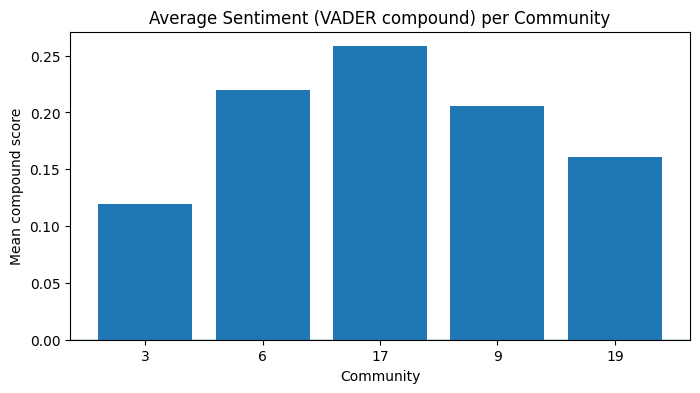

In [ ]:
plt.figure(figsize=(8, 4))
x = comm_summary_full["community"].astype(str)
y = comm_summary_full["mean"]

plt.bar(x, y)
plt.axhline(0, linewidth=1)
plt.title("Average Sentiment (VADER compound) per Community")
plt.xlabel("Community")
plt.ylabel("Mean compound score")
plt.savefig("images/sentiment-distribution-vader.png", dpi=150, bbox_inches="tight")
plt.show()

##Sentiment Distribution (Boxplot-like via matplotlib):

/tmp/ipython-input-4227110478.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in top5_comms], showfliers=False)


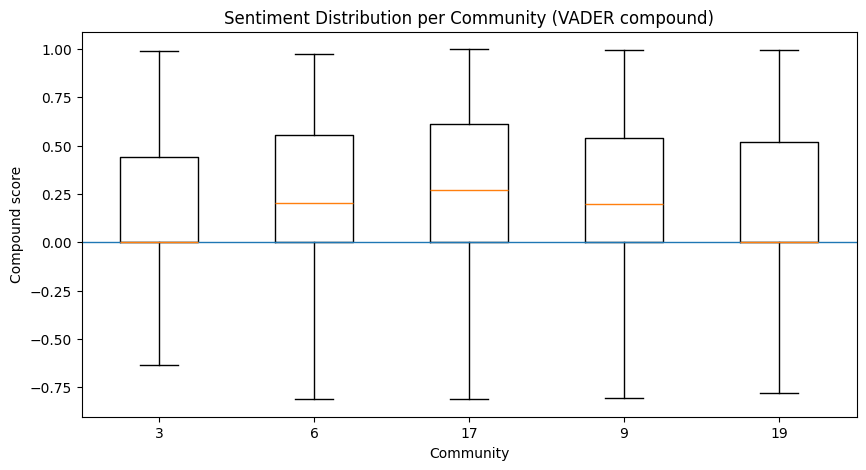

In [ ]:
# Collect sentiment scores per community
data = [df_sent_5[df_sent_5["community"] == c]["sent_compound"].values for c in top_comms_by_comments]

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=[str(c) for c in top_comms_by_comments], showfliers=False)
plt.axhline(0, linewidth=1)
plt.title("Sentiment Distribution per Community (VADER compound)")
plt.xlabel("Community")
plt.ylabel("Compound score")
plt.savefig("images/sentiment-boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

####In this step, we have identified the sentiment distribution for each community. We now examine whether there is a relationship between the sentiment of a community and the sentiment of its hub. Specifically, we analyze the hub’s sentiment as a reflection of the emotional tone of the interactions in which the hub participates.

In [ ]:
# Build a hub DataFrame
df_hubs = (
    df_nodes
    .merge(df_communities, on="user", how="left")
)

df_hubs = df_hubs[  # Keep only relevant columns for hub analysis
    ["user", "community", "degree_centrality", "betweenness_centrality", "closeness_centrality"]
]

df_hubs.head()

,user,community,degree_centrality,betweenness_centrality,closeness_centrality
0,Fit-Elephant8778,0,0.001550,0.002493,0.226554
1,KingOfTheStuffed,0,0.001550,0.000031,0.197368
2,TheLoneWander101,0,0.003876,0.004207,0.231390
3,Soggy_Ground_9323,1,0.007752,0.009410,0.286858
4,rcborg,1,0.012403,0.015518,0.269367


##Select Top-3 Hubs per Community (by Degree Centrality):

In [ ]:
# Keep only hubs belonging to the top-5 analyzed communities
df_hubs_top5 = df_hubs[df_hubs["community"].isin(top_comms_by_comments)].copy()

print("Hubs in top-5 communities:", df_hubs_top5["community"].nunique())

# Select top-3 hubs per community by degree centrality
df_hubs_top3 = (
    df_hubs_top5
    .sort_values(["community", "degree_centrality"], ascending=[True, False])
    .groupby("community", as_index=False)
    .head(3)
    .copy()
)

print("Total hubs selected:", len(df_hubs_top3))
df_hubs_top3.groupby("community")["user"].count()


Hubs in top-5 communities: 5
Total hubs selected: 15


,user
community,
3,3
6,3
9,3
17,3
19,3


##Prepare Community-Level Sentiment Summary:

In [ ]:
# Keeping the average sentiment per community
comm_sent = (
    comm_summary_full[["community", "mean"]]
    .rename(columns={"mean": "community_sent_mean"})
)

comm_sent.head()

,community,community_sent_mean
0,3,0.119361
1,6,0.219281
2,17,0.258084
3,9,0.205258
4,19,0.160370


##Extract All Hub-Related Content (Authored by the Hub):

In [ ]:
# Keep only comments authored by the selected top-3 hubs
df_hub_comments = (
    df_sent_5
    .merge(
        df_hubs_top3[["community", "user"]],
        on=["community", "user"],
        how="inner"
    )
)

print("Number of hub-authored comments:", len(df_hub_comments))
df_hub_comments


Number of hub-authored comments: 378


,user,comment_text,community,sent_compound,sent_label
0,MOXPEARL25,There’s a brand I get at my liquor store that’...,3,0.0000,neutral
1,No_Consideration7925,Never seen it. I like Berry.,6,-0.2755,negative
2,No_Consideration7925,"Black cherry on ice, but really peach not pict...",6,0.5927,positive
3,PinkysAvenger,Have you seen those marvel spiderverse movies?...,19,0.8424,positive
4,No_Consideration7925,You’re 17 you’ll be OK.,6,0.4466,positive
...,...,...,...,...,...
373,SammaJones,Flaming drinks are for flaming idiots. But ye...,3,0.7355,positive
374,SammaJones,"When it comes to rum, I generally look around ...",3,-0.7202,negative
375,No_Consideration7925,Don’t do it! Go to liquor store and buy some n...,6,0.0000,neutral
376,PinkysAvenger,"I'm sorry, but ""haha, you're an alcoholic!"" is...",19,0.3617,positive


##Compute Hub-Level Sentiment:

In [ ]:
# Compute mean sentiment per hub
hub_sent = (
    df_hub_comments
    .groupby(["community", "user"])["sent_compound"]
    .mean()
    .reset_index()
    .rename(columns={
        "user": "hub",
        "sent_compound": "hub_sent_mean"
    })
)

hub_sent

,community,hub,hub_sent_mean
0,3,MOXPEARL25,-0.088169
1,3,SammaJones,0.066815
2,3,petryan55,0.000000
3,6,No_Consideration7925,0.278814
4,6,Prior_Lake_8249,0.443000
5,6,yoyoitsjessepinkman,0.283361
6,9,Jewish-Jedi,0.120400
7,9,JuanG_13,0.220106
8,9,Queasy_Knowledge_853,0.182059
9,17,AggressiveLake433,0.148000


##Build Final Comparison Table (Community vs. Hub):

In [ ]:
final_sentiment_table = (
    df_hubs_top3[["community", "user"]]
    .rename(columns={"user": "hub"})
    .merge(comm_sent, on="community", how="left")                 # community_sent_mean
    .merge(hub_sent, on=["community", "hub"], how="left")         # hub_sent_mean per hub
    .groupby("community", as_index=False)
    .agg(
        community_sent_mean=("community_sent_mean", "first"),     # same within community
        hubs_sent_mean=("hub_sent_mean", "mean"),                 # average over top-3 hubs
        hubs_count=("hub", "nunique"),                            # should be 3 (check)
    )
    .sort_values("community")
    .reset_index(drop=True)
)

final_sentiment_table


,community,community_sent_mean,hubs_sent_mean,hubs_count
0,3,0.119361,-0.007118,3
1,6,0.219281,0.335058,3
2,9,0.205258,0.174188,3
3,17,0.258084,0.363794,3
4,19,0.160370,0.108949,3
